In [1]:
print("步骤1: 设置YOLOv5环境")

import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import torch
from sklearn.model_selection import train_test_split

# YOLOv5路径
YOLOV5_PATH = '/kaggle/input/yolov5/pytorch/default/4/yolov5-6.0'

if os.path.exists(YOLOV5_PATH):
    print(f"找到上传的YOLOv5文件夹: {YOLOV5_PATH}")
    
    os.makedirs('/kaggle/working/yolov5', exist_ok=True)
    
    important_files = ['requirements.txt', 'train.py', 'detect.py', 'export.py', 'val.py']
    for file in important_files:
        src = os.path.join(YOLOV5_PATH, file)
        dst = os.path.join('/kaggle/working/yolov5', file)
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"复制文件: {file}")
    
    important_dirs = ['models', 'utils', 'data']
    for dir_name in important_dirs:
        src_dir = os.path.join(YOLOV5_PATH, dir_name)
        dst_dir = os.path.join('/kaggle/working/yolov5', dir_name)
        if os.path.exists(src_dir):
            shutil.copytree(src_dir, dst_dir)
            print(f"复制文件夹: {dir_name}")
    
    %cd /kaggle/working/yolov5
    
    !pip install -r requirements.txt
    
    %cd /kaggle/working
    
else:
    print("未找到上传的YOLOv5文件夹，请确保已正确上传")

步骤1: 设置YOLOv5环境
找到上传的YOLOv5文件夹: /kaggle/input/yolov5/pytorch/default/4/yolov5-6.0
复制文件: requirements.txt
复制文件: train.py
复制文件: detect.py
复制文件: export.py
复制文件: val.py
复制文件夹: models
复制文件夹: utils
复制文件夹: data
/kaggle/working/yolov5
/kaggle/working


In [2]:
INPUT_DIR = '/kaggle/input' 
WORKING_DIR = '/kaggle/working'
OUTPUT_DIR = f'{WORKING_DIR}/NIH_ChestXray_YOLO'

In [3]:
# 第2步：找到所有图像文件
print("步骤2: 查找图像文件")

image_folders = sorted(glob(f'{INPUT_DIR}/*/images_*'))
print(f"找到 {len(image_folders)} 个图像文件夹: {image_folders}")

all_images = []
for folder in image_folders:
    images = glob(f'{folder}/images/*.png')
    all_images.extend(images)
    print(f"在 {os.path.basename(folder)} 中找到 {len(images)} 张图像")

print(f"总共找到 {len(all_images)} 张图像")

image_path_map = {os.path.basename(img): img for img in all_images}

步骤2: 查找图像文件
找到 12 个图像文件夹: ['/kaggle/input/data/images_001', '/kaggle/input/data/images_002', '/kaggle/input/data/images_003', '/kaggle/input/data/images_004', '/kaggle/input/data/images_005', '/kaggle/input/data/images_006', '/kaggle/input/data/images_007', '/kaggle/input/data/images_008', '/kaggle/input/data/images_009', '/kaggle/input/data/images_010', '/kaggle/input/data/images_011', '/kaggle/input/data/images_012']
在 images_001 中找到 4999 张图像
在 images_002 中找到 10000 张图像
在 images_003 中找到 10000 张图像
在 images_004 中找到 10000 张图像
在 images_005 中找到 10000 张图像
在 images_006 中找到 10000 张图像
在 images_007 中找到 10000 张图像
在 images_008 中找到 10000 张图像
在 images_009 中找到 10000 张图像
在 images_010 中找到 10000 张图像
在 images_011 中找到 10000 张图像
在 images_012 中找到 7121 张图像
总共找到 112120 张图像


In [4]:
# 第3步：数据转换函数实现
print("步骤3: 定义数据转换函数")

def extract_disease_classes_from_bbox(bbox_file):
    """从边界框数据中提取实际标注的疾病类别"""
    bbox_df = pd.read_csv(bbox_file)
    unique_diseases = bbox_df['Finding Label'].unique()
    return sorted(list(unique_diseases))

def convert_bbox_to_yolo(image_width, image_height, bbox):
    """
    将[x, y, width, height]格式的边界框转换为YOLOv5格式[x_center, y_center, width, height]
    其中所有值都相对于图像尺寸进行归一化
    """
    x, y, w, h = bbox
    
    # 确保坐标值有效
    if w <= 0 or h <= 0:
        print(f"警告: 无效的边界框宽度或高度: {bbox}")
        w = max(1, w)  # 至少为1像素
        h = max(1, h)  # 至少为1像素
    
    # 计算中心点坐标
    x_center = (x + w/2) / image_width
    y_center = (y + h/2) / image_height
    
    # 归一化宽度和高度
    w_norm = w / image_width
    h_norm = h / image_height
    
    # 确保归一化坐标在[0,1]范围内
    x_center = max(0, min(1, x_center))
    y_center = max(0, min(1, y_center))
    w_norm = max(0, min(1, w_norm))
    h_norm = max(0, min(1, h_norm))
    
    return [x_center, y_center, w_norm, h_norm]

def create_custom_dataset_split(bbox_file, image_path_map, train_ratio, val_ratio, test_ratio, random_seed=42):
    """
    创建自定义数据集划分，确保所有包含边界框的图像都被合理分配
    
    参数:
        bbox_file: 边界框数据文件路径
        image_path_map: 图像名称到路径的映射字典
        train_ratio, val_ratio, test_ratio: 训练、验证、测试集的比例
        random_seed: 随机种子，确保结果可复现
    
    返回:
        train_imgs, val_imgs, test_imgs: 包含图像名称的列表
    """
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    
    bbox_df = pd.read_csv(bbox_file)
    
    unique_images = bbox_df['Image Index'].unique()

    available_images = [img for img in unique_images if img in image_path_map]
    print(f"找到 {len(available_images)}/{len(unique_images)} 张有边界框的图像")

    image_label_counts = bbox_df.groupby('Image Index')['Finding Label'].nunique().to_dict()
    
    disease_labels = bbox_df.groupby('Image Index')['Finding Label'].apply(list).to_dict()
    
    # 根据标签数量将图像分组
    label_count_groups = {}
    for img in available_images:
        count = image_label_counts.get(img, 0)
        if count not in label_count_groups:
            label_count_groups[count] = []
        label_count_groups[count].append(img)
    
    # 分割测试集和剩余数据
    np.random.seed(random_seed)
    train_val_imgs, test_imgs = [], []
    
    for count, imgs in label_count_groups.items():
        n_test = max(1, int(len(imgs) * test_ratio))
        test_from_group = np.random.choice(imgs, n_test, replace=False).tolist()
        train_val_from_group = [img for img in imgs if img not in test_from_group]
        
        test_imgs.extend(test_from_group)
        train_val_imgs.extend(train_val_from_group)
    
    # 分割训练集和验证集
    val_ratio_adjusted = val_ratio / (train_ratio + val_ratio)  # 调整验证集比例
    train_imgs, val_imgs = train_test_split(
        train_val_imgs,
        test_size=val_ratio_adjusted,
        random_state=random_seed
    )
    
    print(f"数据集划分: {len(train_imgs)} 训练, {len(val_imgs)} 验证, {len(test_imgs)} 测试")
    
    # 确保每个疾病类别在各个集合中都有代表
    disease_classes = bbox_df['Finding Label'].unique()
    
    for disease in disease_classes:
        # 找出含有此疾病的图像
        disease_images = bbox_df[bbox_df['Finding Label'] == disease]['Image Index'].unique()
        disease_images = [img for img in disease_images if img in image_path_map]
        
        # 检查此疾病是否在各个集合中都有代表
        train_has = any(img in train_imgs for img in disease_images)
        val_has = any(img in val_imgs for img in disease_images)
        test_has = any(img in test_imgs for img in disease_images)
        
        # 如果某个集合中没有此疾病，则从其他集合中移动一个样本
        if not train_has and len(disease_images) > 0:
            for img in disease_images:
                if img in val_imgs:
                    val_imgs.remove(img)
                    train_imgs.append(img)
                    break
                elif img in test_imgs:
                    test_imgs.remove(img)
                    train_imgs.append(img)
                    break
        
        if not val_has and len(disease_images) > 0:
            for img in disease_images:
                if img in train_imgs:
                    train_imgs.remove(img)
                    val_imgs.append(img)
                    break
        
        if not test_has and len(disease_images) > 0:
            for img in disease_images:
                if img in train_imgs and len(train_imgs) > 1:
                    train_imgs.remove(img)
                    test_imgs.append(img)
                    break
    
    print("\n各集合中的疾病分布:")
    for dataset_name, dataset in [("训练集", train_imgs), ("验证集", val_imgs), ("测试集", test_imgs)]:
        dataset_diseases = []
        for img in dataset:
            if img in disease_labels:
                dataset_diseases.extend(disease_labels[img])
        
        disease_counts = {}
        for disease in dataset_diseases:
            if disease in disease_counts:
                disease_counts[disease] += 1
            else:
                disease_counts[disease] = 1
        
        print(f"{dataset_name}: {disease_counts}")
    
    return train_imgs, val_imgs, test_imgs

def convert_data(bbox_file, output_dir, image_path_map, image_width=1024, image_height=1024):
    """
    转换NIH胸部X光数据集为YOLOv5格式，使用自定义的数据集划分
    """
    bbox_df = pd.read_csv(bbox_file)
    
    disease_classes = extract_disease_classes_from_bbox(bbox_file)
    print(f"从BBox_List_2017.csv中提取的疾病类别: {disease_classes}")
    
    class_mapping = {disease: idx for idx, disease in enumerate(disease_classes)}
    
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    
    train_imgs, val_imgs, test_imgs = create_custom_dataset_split(
        bbox_file=bbox_file,
        image_path_map=image_path_map,
        train_ratio=0.6,
        val_ratio=0.2,
        test_ratio=0.2,
        random_seed=42
    )
    
    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        f.write(f"# YOLOv5数据集配置\n")
        f.write(f"path: {output_dir}\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/val\n")
        f.write(f"test: images/test\n\n")
        f.write(f"# 类别\n")
        f.write(f"nc: {len(disease_classes)}\n")
        f.write(f"names: {disease_classes}\n")
    
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        if imgs: 
            os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
            os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)
    
    processed_images = 0
    for img_file in tqdm(train_imgs + val_imgs + test_imgs, desc="处理图像"):
        img_bboxes = bbox_df[bbox_df['Image Index'] == img_file]
        
        if img_file in train_imgs:
            split = 'train'
        elif img_file in val_imgs:
            split = 'val'
        elif img_file in test_imgs:
            split = 'test'
        else:
            continue
        
        label_file = os.path.join(output_dir, 'labels', split, img_file.replace('.png', '.txt'))
        
        with open(label_file, 'w') as f:
            for _, row in img_bboxes.iterrows():
                disease = row['Finding Label']
                if disease in class_mapping:
                    class_id = class_mapping[disease]
                    # 确保边界框数据有效
                    try:
                        bbox = [float(row['Bbox [x']), float(row['y']), float(row['w']), float(row['h]'])]
                        if all(v >= 0 for v in bbox) and bbox[2] > 0 and bbox[3] > 0:  # 有效边界框
                            yolo_bbox = convert_bbox_to_yolo(image_width, image_height, bbox)
                            f.write(f"{class_id} {' '.join([str(x) for x in yolo_bbox])}\n")
                    except (ValueError, TypeError) as e:
                        print(f"跳过无效边界框: {row}, 错误: {e}")
        
        src_img = image_path_map[img_file]
        dst_img = os.path.join(output_dir, 'images', split, img_file)
        
        if os.path.exists(dst_img):
            pass
        else:
            try:
                shutil.copy(src_img, dst_img)
            except shutil.SameFileError:
                print(f"警告: 源文件和目标文件相同 - {src_img}")
        
        processed_images += 1

    print("\n验证图像和标签匹配情况：")
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        valid_count = 0
        for img in imgs:
            img_path = os.path.join(output_dir, 'images', split, img)
            label_path = os.path.join(output_dir, 'labels', split, img.replace('.png', '.txt'))
            if os.path.exists(img_path) and os.path.exists(label_path):
                valid_count += 1
        print(f"分割{split}：{valid_count}/{len(imgs)}有效的图像-标签对")

    # 检查空标签文件
    empty_labels = 0
    for split in ['train', 'val', 'test']:
        for label_file in glob(os.path.join(output_dir, 'labels', split, '*.txt')):
            if os.path.getsize(label_file) == 0:
                empty_labels += 1
    print(f"发现{empty_labels}个空标签文件")
    
    print(f"数据集转换完成！处理了 {processed_images} 张图像")
    print(f"训练集大小: {len(train_imgs)}")
    print(f"验证集大小: {len(val_imgs)}")
    print(f"测试集大小: {len(test_imgs)}")
    print(f"目标疾病类别: {disease_classes}")
    
    return disease_classes if processed_images > 0 else []

步骤3: 定义数据转换函数


In [5]:
def visualize_dataset_bboxes(dataset_path, num_samples=5):
    """
    可视化数据集中的图像和对应的边界框，并特别标注x中心点过大的边界框
    
    参数:
        dataset_path: YOLO格式数据集路径
        num_samples: 要可视化的样本数量
    """
    import os
    import random
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2
    from glob import glob
    
    # 获取所有标签文件
    all_label_files = []
    for split in ['train', 'val', 'test']:
        label_dir = os.path.join(dataset_path, 'labels', split)
        if os.path.exists(label_dir):
            label_files = glob(os.path.join(label_dir, '*.txt'))
            all_label_files.extend([(f, split) for f in label_files])
    
    if not all_label_files:
        print("未找到标签文件!")
        return
    
    # 分析所有标签找出有问题的边界框
    problematic_files = []
    
    for label_file, split in all_label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    cls_id, x, y, w, h = map(float, parts)
                    if x > 0.95:  # 设置一个x中心点的阈值
                        img_file = label_file.replace('labels', 'images').replace('.txt', '.png')
                        if os.path.exists(img_file):
                            problematic_files.append((img_file, label_file, split))
                            break  # 一个文件只需要记录一次
                except ValueError:
                    continue
    
    # 打印统计信息
    print(f"发现 {len(problematic_files)} 个含有问题边界框的文件")
    
    # 随机选择样本进行可视化
    if problematic_files:
        samples = random.sample(problematic_files, min(num_samples, len(problematic_files)))
        
        fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4 * len(samples)))
        if len(samples) == 1:
            axes = [axes]
        
        for i, (img_file, label_file, split) in enumerate(samples):
            # 读取图像
            img = cv2.imread(img_file)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape
            
            # 显示原始图像
            axes[i][0].imshow(img)
            axes[i][0].set_title(f"{os.path.basename(img_file)} (Original)")
            axes[i][0].axis('off')
            
            # 显示相同的图像，但标注边界框
            axes[i][1].imshow(img)
            axes[i][1].set_title(f"{os.path.basename(img_file)} (Boxes)")
            axes[i][1].axis('off')
            
            # 读取标签并绘制边界框
            with open(label_file, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    try:
                        cls_id, x, y, w, h = map(float, parts)
                        
                        # 计算像素坐标
                        x_center = int(x * img.shape[1])
                        y_center = int(y * img.shape[0])
                        box_width = int(w * img.shape[1])
                        box_height = int(h * img.shape[0])
                        
                        # 计算左上角坐标
                        x_min = int(x_center - box_width / 2)
                        y_min = int(y_center - box_height / 2)
                        
                        # 绘制边界框
                        color = 'red' if x > 0.95 else 'green'
                        rect = patches.Rectangle(
                            (x_min, y_min), box_width, box_height, 
                            linewidth=2, edgecolor=color, facecolor='none'
                        )
                        axes[i][1].add_patch(rect)
                        
                        # 添加标注
                        axes[i][1].text(
                            x_min, y_min - 5, 
                            f"x={x:.2f}, y={y:.2f}", 
                            color=color, fontsize=10, 
                            bbox=dict(facecolor='white', alpha=0.7)
                        )
                    except ValueError:
                        continue
        
        plt.tight_layout()
        plt.show()
    else:
        print("未找到有问题的边界框!")

def analyze_bbox_distribution(dataset_path):
    """
    分析数据集中边界框坐标的分布情况
    
    参数:
        dataset_path: YOLO格式数据集路径
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from glob import glob
    
    # 收集所有边界框坐标
    x_centers = []
    y_centers = []
    widths = []
    heights = []
    
    # 遍历所有标签文件
    for split in ['train', 'val', 'test']:
        label_dir = os.path.join(dataset_path, 'labels', split)
        if os.path.exists(label_dir):
            label_files = glob(os.path.join(label_dir, '*.txt'))
            
            for label_file in label_files:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            cls_id, x, y, w, h = map(float, parts)
                            x_centers.append(x)
                            y_centers.append(y)
                            widths.append(w)
                            heights.append(h)
                        except ValueError:
                            continue
    
    if not x_centers:
        print("未找到有效的边界框数据!")
        return
    
    # 打印基本统计信息
    print(f"分析了 {len(x_centers)} 个边界框")
    
    # X中心点分布
    x_extreme = sum(1 for x in x_centers if x > 0.95)
    print(f"X中心点 > 0.95 的边界框数量: {x_extreme} ({x_extreme/len(x_centers)*100:.2f}%)")
    
    # 创建图表
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # X中心点分布直方图
    axes[0, 0].hist(x_centers, bins=50, color='blue', alpha=0.7)
    axes[0, 0].set_title('X-centre')
    axes[0, 0].set_xlabel('X-coor')
    axes[0, 0].set_ylabel('frequency')
    axes[0, 0].grid(True)
    
    # Y中心点分布直方图
    axes[0, 1].hist(y_centers, bins=50, color='green', alpha=0.7)
    axes[0, 1].set_title('Y-centre')
    axes[0, 1].set_xlabel('Y-coor')
    axes[0, 1].set_ylabel('frequency')
    axes[0, 1].grid(True)
    
    # 宽度分布直方图
    axes[1, 0].hist(widths, bins=50, color='red', alpha=0.7)
    axes[1, 0].set_title('Bounding box width distribution')
    axes[1, 0].set_xlabel('width')
    axes[1, 0].set_ylabel('frequency')
    axes[1, 0].grid(True)
    
    # 高度分布直方图
    axes[1, 1].hist(heights, bins=50, color='purple', alpha=0.7)
    axes[1, 1].set_title('Bounding box height distribution')
    axes[1, 1].set_xlabel('height')
    axes[1, 1].set_ylabel('frequency')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 创建散点图
    plt.figure(figsize=(10, 8))
    plt.scatter(x_centers, y_centers, alpha=0.3, s=5)
    plt.title('Bounding box centre distribution')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

In [6]:
# 第4步：检查输入数据存在性并转换数据
print("步骤4: 检查输入数据并准备数据集")

# 查找BBox文件
bbox_file_candidates = [
    f'{INPUT_DIR}/BBox_List_2017.csv',
    f'{INPUT_DIR}/data/BBox_List_2017.csv'
]

bbox_file = None
for candidate in bbox_file_candidates:
    if os.path.exists(candidate):
        bbox_file = candidate
        print(f"✓ 找到文件: {bbox_file}")
        break

# 如果没有找到文件，打印错误并显示目录结构
if not bbox_file:
    print("✗ 未找到BBox_List_2017.csv文件")
    print("列出INPUT_DIR下的文件:")
    !ls -la {INPUT_DIR}
    
    # 如果有data子目录，也列出
    if os.path.exists(f'{INPUT_DIR}/data'):
        print("列出INPUT_DIR/data下的文件:")
        !ls -la {INPUT_DIR}/data

# 转换数据
if bbox_file and len(image_path_map) > 0:
    disease_classes = convert_data(
        bbox_file=bbox_file,
        output_dir=OUTPUT_DIR,
        image_path_map=image_path_map,
    )
else:
    print("数据文件缺失，无法继续")
    disease_classes = []

# 数据集结构
if os.path.exists(OUTPUT_DIR) and disease_classes:
    print("\n数据集结构:")
    train_dir = os.path.join(OUTPUT_DIR, 'labels', 'train')
    if os.path.exists(train_dir) and len(os.listdir(train_dir)) > 0:
        !ls -la {train_dir} | head -5
        print("...")
    
    images_train_dir = os.path.join(OUTPUT_DIR, 'images', 'train')
    if os.path.exists(images_train_dir) and len(os.listdir(images_train_dir)) > 0:
        !ls -la {images_train_dir} | head -5
        print("...")
    
    !cat {OUTPUT_DIR}/data.yaml

步骤4: 检查输入数据并准备数据集
✓ 找到文件: /kaggle/input/data/BBox_List_2017.csv
从BBox_List_2017.csv中提取的疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']
找到 880/880 张有边界框的图像
数据集划分: 528 训练, 177 验证, 175 测试

各集合中的疾病分布:
训练集: {'Mass': 58, 'Cardiomegaly': 95, 'Pneumothorax': 58, 'Effusion': 88, 'Infiltrate': 70, 'Pneumonia': 74, 'Nodule': 50, 'Atelectasis': 97}
验证集: {'Nodule': 9, 'Atelectasis': 47, 'Cardiomegaly': 30, 'Infiltrate': 27, 'Effusion': 35, 'Pneumothorax': 17, 'Mass': 12, 'Pneumonia': 21}
测试集: {'Nodule': 20, 'Atelectasis': 36, 'Cardiomegaly': 21, 'Effusion': 30, 'Infiltrate': 26, 'Mass': 15, 'Pneumothorax': 23, 'Pneumonia': 25}


处理图像: 100%|██████████| 880/880 [00:09<00:00, 93.08it/s]



验证图像和标签匹配情况：
分割train：528/528有效的图像-标签对
分割val：177/177有效的图像-标签对
分割test：175/175有效的图像-标签对
发现0个空标签文件
数据集转换完成！处理了 880 张图像
训练集大小: 528
验证集大小: 177
测试集大小: 175
目标疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']

数据集结构:
total 2136
drwxr-xr-x 2 root root 20480 Mar 22 09:19 .
drwxr-xr-x 5 root root  4096 Mar 22 09:19 ..
-rw-r--r-- 1 root root    80 Mar 22 09:19 00000149_006.txt
-rw-r--r-- 1 root root    81 Mar 22 09:19 00000181_061.txt
ls: write error: Broken pipe
...
total 209548
drwxr-xr-x 2 root root  20480 Mar 22 09:19 .
drwxr-xr-x 5 root root   4096 Mar 22 09:19 ..
-rw-r--r-- 1 root root 383437 Mar 22 09:19 00000149_006.png
-rw-r--r-- 1 root root 356419 Mar 22 09:19 00000181_061.png
ls: write error: Broken pipe
...
# YOLOv5数据集配置
path: /kaggle/working/NIH_ChestXray_YOLO
train: images/train
val: images/val
test: images/test

# 类别
nc: 8
names: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneu

步骤4.5: 分析数据集问题
分析了 984 个边界框
X中心点 > 0.95 的边界框数量: 0 (0.00%)


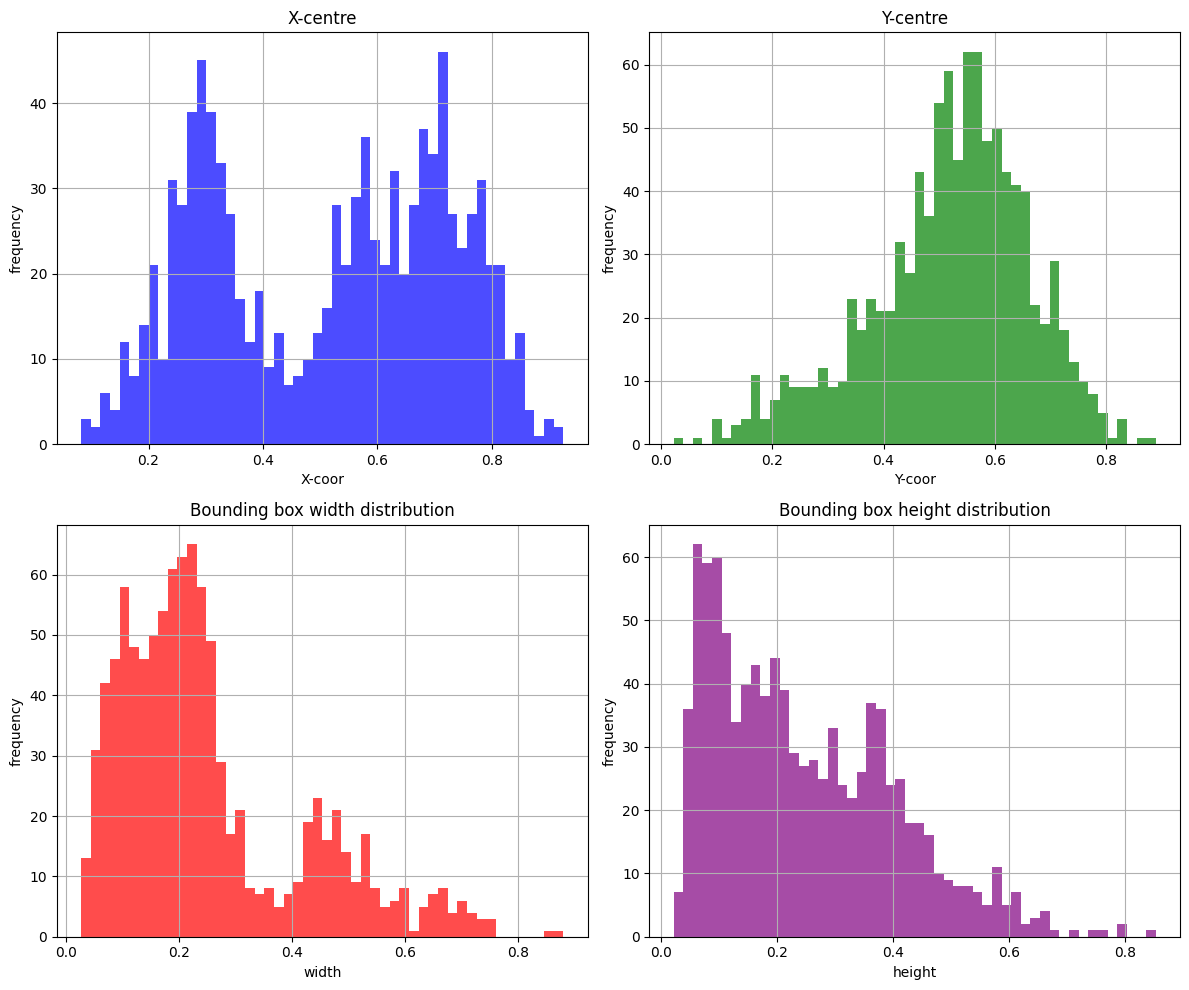

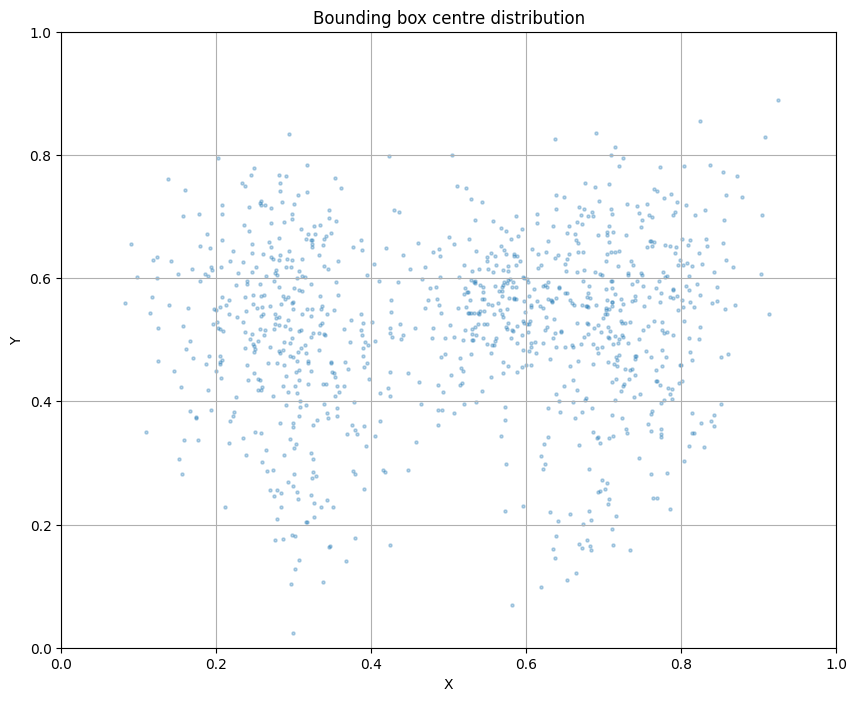

发现 0 个含有问题边界框的文件
未找到有问题的边界框!


In [7]:
print("步骤4.5: 分析数据集问题")

analyze_bbox_distribution(OUTPUT_DIR)

visualize_dataset_bboxes(OUTPUT_DIR, num_samples=5)

In [8]:
# 第5步：训练YOLOv5模型
# 在第5步训练之前添加
print("检查图像和标签质量...")
import cv2
from tqdm import tqdm

# 检查训练集中的图像和标签
split = 'train'
img_dir = os.path.join(OUTPUT_DIR, 'images', split)
label_dir = os.path.join(OUTPUT_DIR, 'labels', split)
invalid_count = 0
small_image_count = 0

for img_file in tqdm(os.listdir(img_dir)[:100]):  # 仅检查前100张图像作为样本
    img_path = os.path.join(img_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace('.png', '.txt'))
    
    # 检查图像是否可读
    try:
        img = cv2.imread(img_path)
        if img is None:
            print(f"无法读取图像: {img_path}")
            invalid_count += 1
            continue
            
        # 检查图像尺寸
        h, w = img.shape[:2]
        if h < 10 or w < 10:  # 过小的图像
            print(f"图像尺寸过小: {img_path}, {w}x{h}")
            small_image_count += 1
        
        # 检查标签文件格式
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        print(f"标签格式错误: {label_path}, {line}")
                        invalid_count += 1
                        break
                    
                    # 检查坐标是否在[0,1]范围内
                    try:
                        cls_id, x, y, w, h = map(float, parts)
                        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                            print(f"坐标范围错误: {label_path}, {line}")
                            invalid_count += 1
                            break
                    except ValueError:
                        print(f"无法解析数值: {label_path}, {line}")
                        invalid_count += 1
                        break
        else:
            print(f"标签文件不存在: {label_path}")
            invalid_count += 1
                
    except Exception as e:
        print(f"处理错误 {img_path}: {str(e)}")
        invalid_count += 1

print(f"检查结果: 发现{invalid_count}个无效样本, {small_image_count}个小尺寸图像")
print("直接检查文件数量：")
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(OUTPUT_DIR, 'images', split)
    label_dir = os.path.join(OUTPUT_DIR, 'labels', split)
    if os.path.exists(img_dir) and os.path.exists(label_dir):
        img_count = len(os.listdir(img_dir))
        label_count = len(os.listdir(label_dir))
        print(f"分割{split}：{img_count}张图像，{label_count}个标签")

print("步骤5: 训练YOLOv5模型")

if disease_classes and os.path.exists(OUTPUT_DIR):
    print(f"开始训练模型，数据集路径: {OUTPUT_DIR}")
    
    # 设置训练参数
    BATCH_SIZE = 8
    EPOCHS = 50
    IMAGE_SIZE = 640
    MODEL_TYPE = 's' 
    
    %cd /kaggle/working/yolov5
    !python train.py --img {IMAGE_SIZE} --batch {BATCH_SIZE} --epochs {EPOCHS} \
                     --data {OUTPUT_DIR}/data.yaml \
                     --cfg models/yolov5{MODEL_TYPE}.yaml \
                     --weights yolov5{MODEL_TYPE}.pt \
                     --name chest_xray_model \
                     --cache

    %cd /kaggle/working
    
    print("训练完成！")
else:
    print("数据集准备不完整，无法开始训练")

检查图像和标签质量...


100%|██████████| 100/100 [00:01<00:00, 78.80it/s]


检查结果: 发现0个无效样本, 0个小尺寸图像
直接检查文件数量：
分割train：528张图像，528个标签
分割val：177张图像，177个标签
分割test：175张图像，175个标签
步骤5: 训练YOLOv5模型
开始训练模型，数据集路径: /kaggle/working/NIH_ChestXray_YOLO
/kaggle/working/yolov5
2025-03-22 09:20:14.082694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-22 09:20:14.278374: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-22 09:20:14.333679: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B accoun

In [9]:
# Step 6: Model validation and analysis of test results
print("Step 6: Model validation and analysis of test results")

trained_model_path = '/kaggle/working/best.pt'

if os.path.exists(trained_model_path) and disease_classes:
    print(f"Finding trained models: {trained_model_path}")
    
    TEST_DATA_PATH = os.path.join(OUTPUT_DIR, 'data.yaml')
    TEST_BATCH_SIZE = 16
    TEST_IMG_SIZE = 640
    TEST_CONF = 0.25
    
    print("Begin validation of the test set...")
    
    %cd /kaggle/working/yolov5
    
    !python val.py --weights {trained_model_path} \
                   --data {TEST_DATA_PATH} \
                   --img-size {TEST_IMG_SIZE} \
                   --batch-size {TEST_BATCH_SIZE} \
                   --conf-thres {TEST_CONF} \
                   --task test \
                   --verbose \
                   --save-txt \
                   --save-conf \
                   --name chest_xray_test_results

Step 6: Model validation and analysis of test results
